# **Time-Series Forecasting of Agricultural Production**


The project aims to forecast agricultural production using historical time-series data obtained from the food Agriculture organisation corpotate statistical Database (FAOSTAT) maintained by the Food and Agriculture Organization (FAO) of the United Nations.

The dataset provides long-term, publicly available agricultural production statistics at country and crop level.

The project is to clearly define the research objective. The study will focus on forecasting the future production of a selected crop in a specific country using historical production data. This focused scope ensures that the analysis remains manageable and suitable for time-series modelling.

The dataset will be explored to understand its structure and key variables. Important fields include the country (Area), crop type (Item), production measure (Element), year, and production value. Understanding these variables is essential to correctly construct the time series.

1. Import Required Libraries:

Explanation:

We import libraries for data handling, plotting, statistical tests, time-series models, machine learning metrics, and deep learning.

In [36]:
import pandas as pd # this data frame used for reading, filtering, and reshaping tabular data
import numpy as np # numerical operations
import matplotlib.pyplot as plt # used for plotting the time series
import matplotlib.ticker as ticker
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

2. Loading the FAOSTAT Dataset

Explanation:

We load the original FAOSTAT CSV file into a pandas DataFrame.

In [37]:
# storing the location of your CSV file
file_path = "Production_Crops_Livestock_E_All_Data.csv"
df = pd.read_csv(file_path)
df.head()

/tmp/ipykernel_975/501396160.py:3: DtypeWarning: Columns (11,14,17,20,23,26,29,32,35,38,41,44,47,50,53,56,59,62,65,68,71,74,77,80,83,86,89,92,95,98,101,104,107,110,113,116,119,122,125,128,131,134,137,140,143,146,149,152,155,158,161,164,167,170,173,176,179,182,185,188,191,194,197,200) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N,Y2024,Y2024F,Y2024N
0,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5312,Area harvested,ha,0.0,...,NaN,36462.0,A,NaN,37000.0,A,NaN,39794.00,I,NaN
1,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5412,Yield,kg/ha,NaN,...,NaN,1742.0,A,NaN,1810.8,A,NaN,1741.90,E,NaN
2,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5510,Production,t,0.0,...,NaN,63515.0,A,NaN,67000.0,A,NaN,69315.64,I,NaN
3,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5312,Area harvested,ha,NaN,...,NaN,25403.0,E,NaN,25439.0,E,NaN,25400.00,E,NaN
4,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5412,Yield,kg/ha,NaN,...,NaN,704.0,E,NaN,704.0,E,NaN,704.30,E,NaN


3. Filter Dataset (Country, Crop, Production)

Explanation:

We select:

	One country
	One crop
	Production values only
  
Creates a clean univariate time series.

In [38]:
#countries = ["India","United Kindom","United States of America"]
country = "India"
crop = "Wheat"
df_filtered = df[
    (df["Area"] == country) &
    #(df["Area"].isin(countries))&
    (df["Item"] == crop) &
    (df["Element"] == "Production")]
df_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N,Y2024,Y2024F,Y2024N
25786,100,'356,India,15,'0111,Wheat,5510,Production,t,10997000.0,...,NaN,107742070.0,A,NaN,1.105537e+08,A,NaN,113292368.0,A,NaN


In [39]:
Unit = df_filtered["Unit"].iloc[0]

4. Data Cleaning

Explanation:

Removing missing values and ensure production values are positive.

In [40]:
year_columns = [col for col in df_filtered.columns if col.startswith("Y")]
ts = df_filtered[year_columns].T
ts.index = [int(''.join(filter(str.isdigit, year))) for year in year_columns]
ts.columns = ["Production"]
ts.head()

,Production
1961,10997000.0
1961,A
1961,NaN
1962,12072000.0
1962,A


5. Converting to Time Series Format

Explanation:

We convert Year into a datetime index, which is required for time-series models.

In [41]:
# The 'Year' column has already been converted to a datetime index in the previous step.
# Therefore, the following two lines are redundant and cause a KeyError.
ts["Production"] = pd.to_numeric(ts["Production"],errors="coerce")

# Removing missing values
ts = ts.dropna()

# Removing zero or negative values
ts = ts[ts["Production"] > 0]

# Converting to datetime
ts.index = pd.to_datetime(ts.index, format="%Y")

# Sorting chronologically
ts = ts.sort_index()
print("Cleaned Data Preview:")
print(ts.head())
print("Total Observations:", len(ts))


Cleaned Data Preview:
            Production
1961-01-01  10997000.0
1962-01-01  12072000.0
1963-01-01  10776000.0
1964-01-01   9853000.0
1965-01-01  12257000.0
Total Observations: 64


6. Exploratory Data Analysis (EDA)

Plotting the Time Series

Explanation:

This shows long-term production trends.

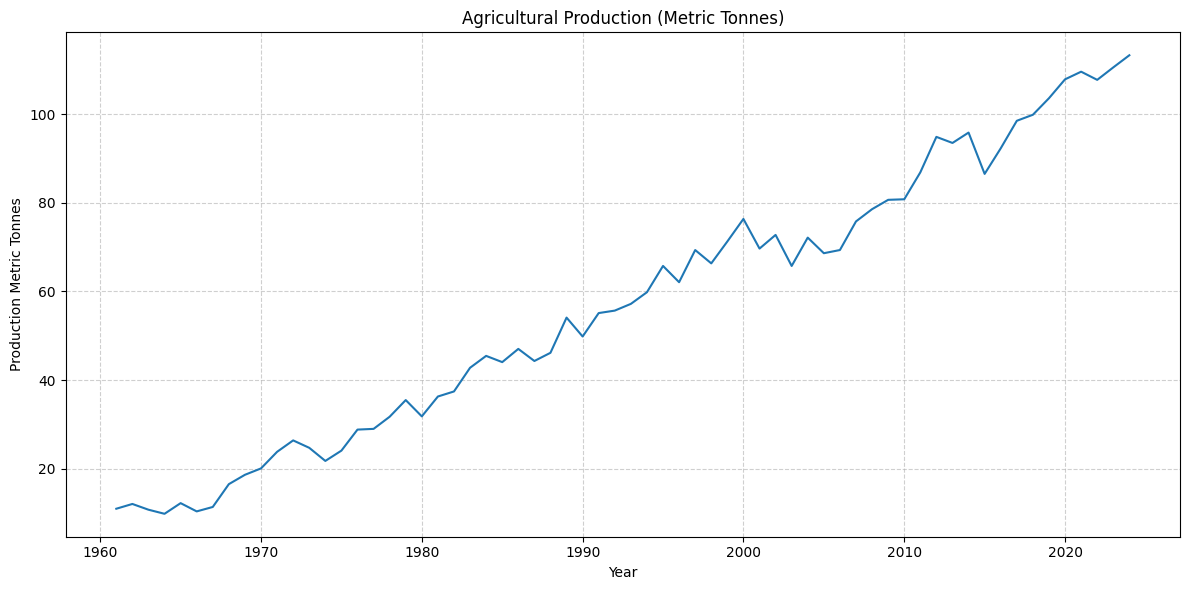

In [42]:
ts["Production_Million"] = ts["Production"] / 1_000_000
plt.figure(figsize=(12,6))
plt.plot(ts.index, ts["Production_Million"])

plt.title("Agricultural Production (Metric Tonnes)")
plt.xlabel("Year")
plt.ylabel("Production Metric Tonnes")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

7. Training and Testing data

Training data is used to teach the model and estimate parameters

*   it trains past data

Testing data is used to evaluate the model's performance on unseen data to ensure it generatizes well.

*   it tests future data

 Models may memorize, gives fake high accuracy, called Overfitting.

We train and test on the same data

In [43]:
#Training-testing(80% train, 20% test)
#Spliting the data into 80% training and 20% testing
train_size = int(len(ts) * 0.8)
train = ts.iloc[:train_size]
test = ts.iloc[train_size:]
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 51
Test size: 13


8. Baseline model:

It provides a benchmark to ensure that advanced models genuinely improve forecasting performance beyond simple presistence assumptions.

This models can called as Naïve forecasting

**Ploting Basline model:**